# Black-Scholes Options Trading

The **Black-Scholes model** is a cornerstone of modern quantitative finance. It provides a theoretical framework for pricing European-style options by assuming that the underlying asset follows a **geometric Brownian motion** with constant volatility.

---

#### 1️⃣ Black-Scholes Option Pricing Formula

For a **call option**, the solution to the Black-Scholes partial differential equation (PDE) is:

$$
C = S_t \, \Phi(d_1) - K e^{-rt} \, \Phi(d_2)
$$

Where:

- $ C $ = Call option price  
- $ S_t $ = Current stock price  
- $ K $ = Strike price  
- $ r $ = Risk-free interest rate  
- $ t $ = Time to expiration (in years)  
- $ \Phi(x) $ = Cumulative distribution function (CDF) of the standard normal  


#### 2️⃣ Standard Normal CDF

$$
\Phi(x) = \int_{-\infty}^x \frac{1}{\sqrt{2\pi}} e^{-s^2/2} \, ds
$$

This represents the probability that a standard normal variable is less than or equal to $ x $.


#### 3️⃣ Calculating $ d_1 $ and $ d_2 $

$$
d_1 = \frac{\ln(S_t / K) + (r + \frac{\sigma^2}{2}) t}{\sigma \sqrt{t}}
$$

$$
d_2 = d_1 - \sigma \sqrt{t}
$$

Where $ \sigma $ is the volatility of the underlying asset.


#### 4️⃣ Geometric Brownian Motion Assumption

The underlying stock price is assumed to follow:

$$
\frac{dS_t}{S_t} = \mu \, dt + \sigma \, dW_t
$$

Where:

- $ \mu $ = Drift (expected return)  
- $ \sigma $ = Volatility  
- $ W_t $ = Standard Wiener process (Brownian motion)  

This stochastic differential equation models **continuous-time price evolution** with randomness.

---

#### Practical Insights for Trading

- **Delta-Hedging:** The model allows constructing risk-neutral hedges based on $\Delta = \Phi(d_1)$.  
- **Implied Volatility:** Observed option prices can be inverted to compute market-implied volatility.  
- **Limitations:** Assumes constant volatility and no dividends; real markets often deviate, requiring adjustments (e.g., Black-Scholes-Merton with dividends or stochastic volatility models).  

By understanding these formulas, traders can price options, evaluate risk, and implement systematic hedging strategies.

Import the necessary libraries

In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import qfin as qf

In [2]:
def black_scholes_call(S, K, sigma, r, t):
  d1 = (np.log(S/K) + (r + ((sigma**2)/2))*t) / (sigma * np.sqrt(t))
  d2 = d1 - (sigma * np.sqrt(t))
  C = S * norm.cdf(d1) - K * np.exp(-r*t) * norm.cdf(d2)
  return C

Sample run

In [3]:
black_scholes_call(100, 100, .3, .05, 1)

14.231254785985819

**Making and Losing Money Trading Options**

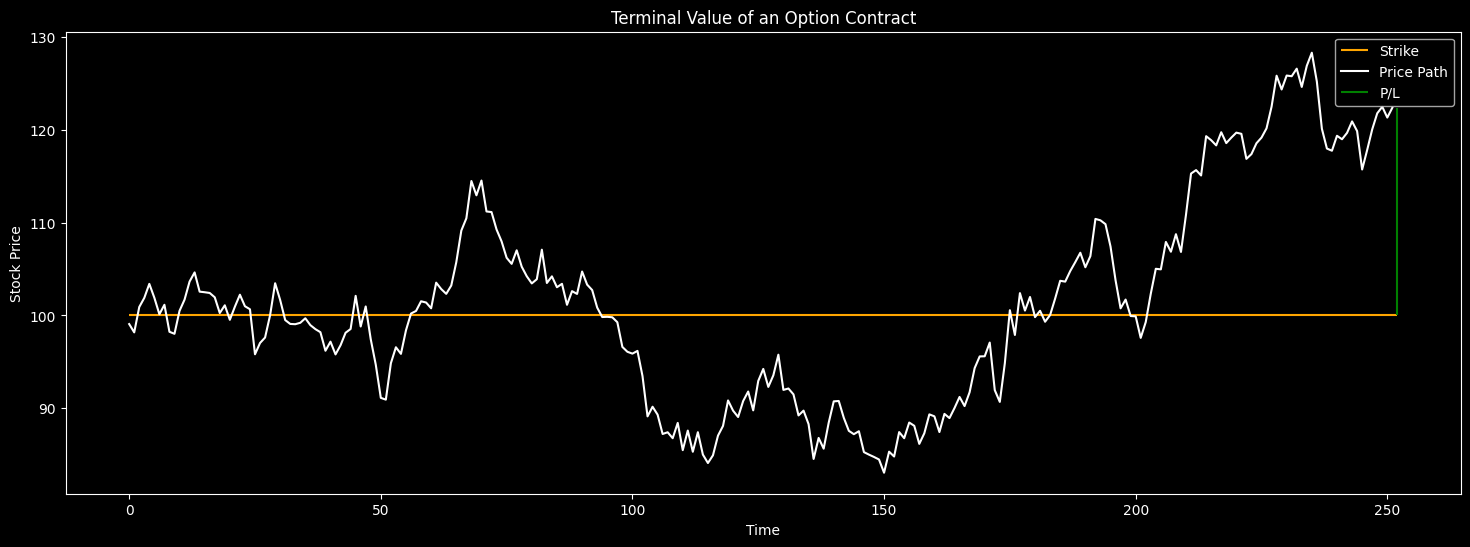

Premium at t=0: 14.231254785985819
P/L: 8.144159125396406


In [12]:
# Simulate dynamics of the underlying according to Geometric Brownian Motion
path = qf.simulations.GeometricBrownianMotion(100, 0.05, .3, 1/252, 1)

# Create a chart of the price path and the strike price
plt.figure(figsize=(18, 6))
plt.title("Terminal Value of an Option Contract")
plt.hlines(100, 0, 252, label='Strike', color='orange')
plt.plot(path.simulated_path, label='Price Path', color='white')
if max(path.simulated_path[-1] - 100, 0) == 0:
  plt.vlines(252, path.simulated_path[-1], 100, color='red', label="P/L")
else:
  plt.vlines(252, 100, path.simulated_path[-1], color='green', label="P/L")
plt.style.use('dark_background')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

# print the premium and the resulting P/L
print("Premium at t=0:", black_scholes_call(100, 100, .3, .05, 1))
print("P/L:", max(path.simulated_path[-1] - 100, 0) - black_scholes_call(100, 100, .3, .05, 1))

**How to Make Money using the Black-Scholes Model**

Let $T$ be a trading strategy such that options are bought/sold when there is a theoretical discrepency between the model price and market maker quote.

$$\mathbb{E}T > 0 \implies \text{ Positive P/L Over Time}$$

In [5]:
print("Call Price:", black_scholes_call(100, 100, .3, .05, 1))
print("Market Maker Quote:", "13.43 @ 14.10")
print("Trade Edge:", black_scholes_call(100, 100, .3, .05, 1) - 14.10)

Call Price: 14.231254785985819
Market Maker Quote: 13.43 @ 14.10
Trade Edge: 0.13125478598581886


**Computing the P/L Edge with Respect to the Model Dynamics**

In [6]:
premium = 14.10 * 100
pls = []

for i in range(100000):
  path = qf.simulations.GeometricBrownianMotion(100, 0.05, .3, 1/252, 1)
  pls.append(max(path.simulated_path[-1] - 100, 0)*100 - premium)

np.mean(pls)

83.76340553608458

**Simulating an Equity Curve Assuming Underlying Dynamics**

The following line of code creates a **Geometric Brownian Motion (GBM)** simulation:

```python
path = qf.simulations.GeometricBrownianMotion(100, -0.5, 0.3, 1/252, 1)
```

| Parameter | Value | Description |
|-----------|-------|-------------|
| Initial stock price \(S_0\) | 100 | The starting price of the simulated asset. |
| Drift (\(\mu\)) | -0.5 | Expected return per time step; negative implies a downward trend. |
| Volatility (\(\sigma\)) | 0.3 | Standard deviation of returns; determines fluctuation magnitude. |
| Time step (\(dt\)) | 1/252 | Fraction of a year for each simulation step (daily, assuming 252 trading days). |
| Time horizon (\(T\)) | 1 | Total duration of the simulation in years. |



Please adjust and experiment with different values depending on the context of your analysis in order to visualise how the option trade will perform over time


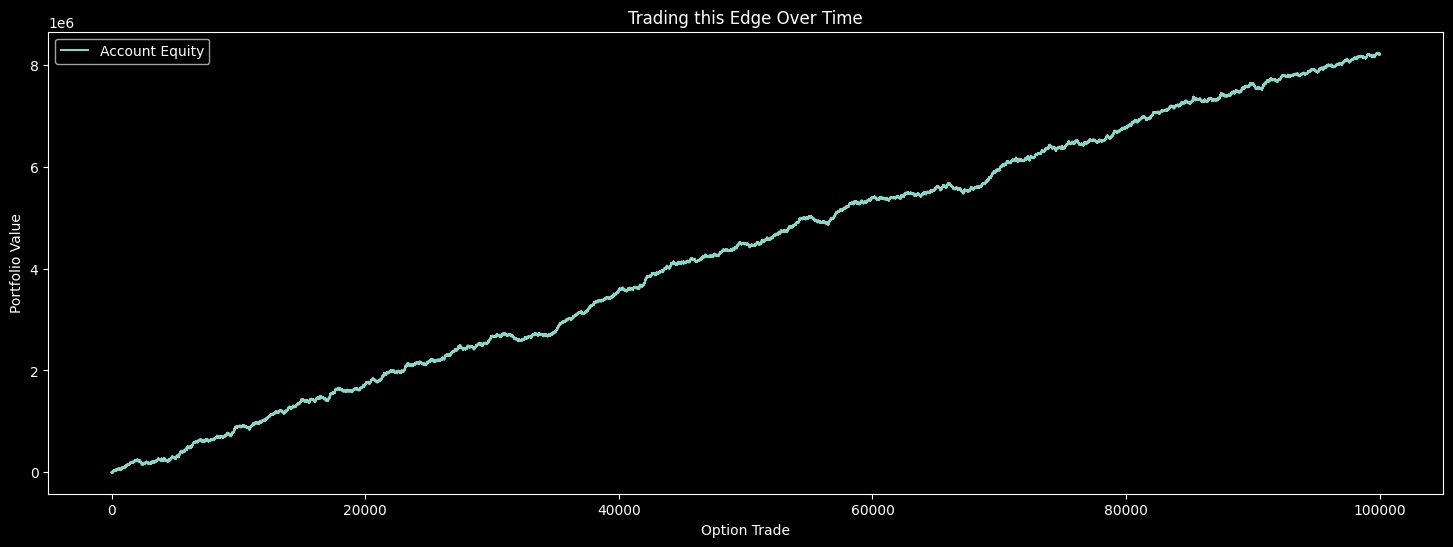

In [7]:
# Define the premium option price
premium = 14.10 * 100
num_of_simulations = 100000
initial_account_value = 100
drift = 0.03
volatility = 0.2
time_step = 1/252
time_horizon = 2

pls = []

for i in range(num_of_simulations):
  path = qf.simulations.GeometricBrownianMotion(initial_account_value, drift, volatility, time_step, time_horizon)
  pls.append(max(path.simulated_path[-1] - initial_account_value, 0)*100 - premium)

plt.figure(figsize=(18, 6))
plt.title("Trading this Edge Over Time")
plt.plot(np.cumsum(pls), label="Account Equity")
plt.style.use('dark_background')
plt.xlabel('Option Trade')
plt.ylabel('Portfolio Value')
plt.legend()
plt.show()

### Some Issues Trading Model Prices

- Non-stationarity in parameterization
- Volatility is not constant and lacks clustering heuristic
- Dynamics do not include jumps
- etc.